In [1]:
import sklearn
import numpy as np

## Load the dataset

In [ ]:
from sklearn.datasets import fetch_20newsgroups
#print(fetch_20newsgroups().keys())
# print(fetch_20newsgroups().target_names)
# print(fetch_20newsgroups(subset='train').data[9])

categories = [          # comment categories for training model on all categories
    'sci.med',           # medical science articles
    'rec.sport.hockey',  # hockey sports articles
    'comp.graphics',     # computer graphics articles
    'talk.politics.guns' # gun politics articles
]

# load train and test data (all categories)
# train_data = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'),random_state=42)
# test_data = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'),random_state=42)

# load train and test data (selected categories)
train_data = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'),random_state=42)
test_data = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'),random_state=42)


print("Training samples:", len(train_data.data))
print("Test samples    :", len(test_data.data))
print("Categories      :", train_data.target_names)
print()

# Look at one example
print("Sample text:")
print(train_data.data[0][:300])
print()
print("Label:", train_data.target_names[train_data.target[0]])

Training samples: 11314
Test samples    : 7532
Categories      : ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']

Sample text:
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I k

Label: rec.autos


## Explore the data before touching any model

In [3]:
# Check class distribution — are classes balanced?
unique, counts = np.unique(train_data.target, return_counts=True)
print("Class distribution in training set:")
for label, count in zip(train_data.target_names, counts):
    bar = '█' * (count // 20)
    print(f"  {label:<25} {count:4d}  {bar}")

print()
# Check average text length
lengths = [len(text.split()) for text in train_data.data]
print(f"Average words per document : {np.mean(lengths):.0f}")
print(f"Shortest document          : {np.min(lengths)} words")
print(f"Longest document           : {np.max(lengths)} words")

# Look at 3 samples from different categories
for i in range(3):
    print(f"\n--- Sample {i+1} | Category: {train_data.target_names[train_data.target[i]]} ---")
    print(train_data.data[i][:200])

Class distribution in training set:
  alt.atheism                480  ████████████████████████
  comp.graphics              584  █████████████████████████████
  comp.os.ms-windows.misc    591  █████████████████████████████
  comp.sys.ibm.pc.hardware   590  █████████████████████████████
  comp.sys.mac.hardware      578  ████████████████████████████
  comp.windows.x             593  █████████████████████████████
  misc.forsale               585  █████████████████████████████
  rec.autos                  594  █████████████████████████████
  rec.motorcycles            598  █████████████████████████████
  rec.sport.baseball         597  █████████████████████████████
  rec.sport.hockey           600  ██████████████████████████████
  sci.crypt                  595  █████████████████████████████
  sci.electronics            591  █████████████████████████████
  sci.med                    594  █████████████████████████████
  sci.space                  593  █████████████████████████████
  soc.rel

In [4]:
# print(train_data.data[1][:200])

## Build first Pipeline (tf-idf + logistic reg)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Build the pipeline — two steps chained together
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words  = 'english',   # remove stopwords
        max_features = 10000,      # keep top 10,000 words by frequency
        ngram_range = (1, 1),      # start with unigrams only
    )),
    ('clf', LogisticRegression(
        max_iter = 1000,           # enough iterations to converge
        random_state = 42,
    )),
])

# Train
pipeline.fit(train_data.data, train_data.target)

# Evaluate
y_pred = pipeline.predict(test_data.data)
accuracy = accuracy_score(test_data.target, y_pred)
print(f"Accuracy: {accuracy:.4f}")  # should be around 0.88-0.90 already

Accuracy: 0.6694


In [6]:
print(classification_report(test_data.target,y_pred,target_names=test_data.target_names))

#                     precision    recall  f1-score   support

#      comp.graphics       0.91      0.93      0.92       389
#   rec.sport.hockey       0.97      0.92      0.94       399
#            sci.med       0.83      0.90      0.86       396
# talk.politics.guns       0.90      0.85      0.87       364

#           accuracy                           0.90      1548
#          macro avg       0.90      0.90      0.90      1548
#       weighted avg       0.90      0.90      0.90      1548

                          precision    recall  f1-score   support

             alt.atheism       0.47      0.44      0.46       319
           comp.graphics       0.63      0.70      0.66       389
 comp.os.ms-windows.misc       0.64      0.61      0.62       394
comp.sys.ibm.pc.hardware       0.64      0.61      0.62       392
   comp.sys.mac.hardware       0.73      0.65      0.69       385
          comp.windows.x       0.81      0.71      0.76       395
            misc.forsale       0.75      0.78      0.76       390
               rec.autos       0.70      0.69      0.70       396
         rec.motorcycles       0.47      0.76      0.58       398
      rec.sport.baseball       0.78      0.78      0.78       397
        rec.sport.hockey       0.88      0.86      0.87       399
               sci.crypt       0.87      0.67      0.76       396
         sci.electronics       0.54      0.58      0.56       393
                 sci.med       0.74      0.76      0.75       396
         

## Inspect Confusion Matrix

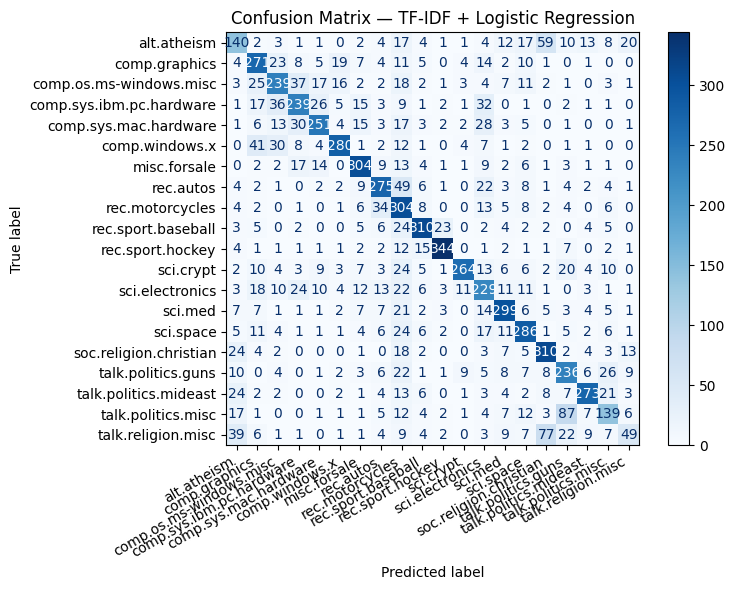


Raw confusion matrix:
[[140   2   3   1   1   0   2   4  17   4   1   1   4  12  17  59  10  13
    8  20]
 [  4 271  23   8   5  19   7   4  11   5   0   4  14   2  10   1   0   1
    0   0]
 [  3  25 239  37  17  16   2   2  18   2   1   3   4   7  11   2   1   0
    3   1]
 [  1  17  36 239  26   5  15   3   9   1   2   1  32   0   1   0   2   1
    1   0]
 [  1   6  13  30 251   4  15   3  17   3   2   2  28   3   5   0   1   0
    0   1]
 [  0  41  30   8   4 280   1   2  12   1   0   4   7   1   2   0   1   1
    0   0]
 [  0   2   2  17  14   0 304   9  13   4   1   1   9   2   6   1   3   1
    1   0]
 [  4   2   1   0   2   2   9 275  49   6   1   0  22   3   8   1   4   2
    4   1]
 [  4   2   0   1   0   1   6  34 304   8   0   0  13   5   8   2   4   0
    6   0]
 [  3   5   0   2   0   0   5   6  24 310  23   0   2   4   2   2   0   4
    5   0]
 [  4   1   1   1   1   1   2   2  12  15 344   0   1   2   1   1   7   0
    2   1]
 [  2  10   4   3   9   3   7   3  24   5 

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(test_data.target, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = test_data.target_names
)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.xticks(rotation=30, ha='right')
plt.title("Confusion Matrix — TF-IDF + Logistic Regression")
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Each row = actual class. Each column = predicted class.
# The diagonal = correct predictions.
# Off-diagonal = where the model gets confused between categories.
print("\nRaw confusion matrix:")
print(cm)

## Version 2 : Add bigrams and Tune Parameters

In [8]:
# Version 2 — better parameters
from sklearn.svm import LinearSVC


pipeline_v2 = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words   = 'english',
        max_features = 20000,       # more vocabulary
        ngram_range  = (1, 2),      # unigrams + bigrams
        sublinear_tf = True,        # log-scale term frequency — helps a lot
        min_df       = 2,           # word must appear in at least 2 docs
        max_df       = 0.95,        # ignore words in more than 95% of docs
    )),
    # ('clf', LinearSVC(
    #     C            = 5.0,         # regularisation — higher C = less regularisation
    #     max_iter     = 1000,
    #     random_state = 42
    # )),
    ('clf', LogisticRegression(
        C            = 5.0,         # regularisation — higher C = less regularisation
        max_iter     = 1000,
        solver       = 'lbfgs',
       # multi_class  = 'auto',
        random_state = 42
    )),
])

pipeline_v2.fit(train_data.data, train_data.target)
y_pred_v2 = pipeline_v2.predict(test_data.data)

accuracy_v2 = accuracy_score(test_data.target, y_pred_v2)
print(f"Version 1 accuracy: {accuracy:.4f}")
print(f"Version 2 accuracy: {accuracy_v2:.4f}")
print(f"Improvement: +{(accuracy_v2 - accuracy)*100:.2f}%")

Version 1 accuracy: 0.6694
Version 2 accuracy: 0.6835
Improvement: +1.41%


## What words the model learned?

In [9]:
# Extract components from pipeline
vectorizer = pipeline_v2.named_steps['tfidf']
classifier = pipeline_v2.named_steps['clf']
feature_names = vectorizer.get_feature_names_out()

print("Top 15 most distinctive words per category:\n")
for i, category in enumerate(train_data.target_names):
    # The classifier learned a weight for each feature per class
    # Highest weights = most predictive words for that class
    top_indices = np.argsort(classifier.coef_[i])[-15:]
    top_words   = [feature_names[j] for j in top_indices]
    print(f"{category}:")
    print(f"  {', '.join(top_words)}")
    print()

Top 15 most distinctive words per category:

alt.atheism:
  religious, bake, cruel, objective, atheist, deletion, god, bobby, islamic, islam, motto, bible, atheists, atheism, religion

comp.graphics:
  cview, vesa, format, algorithm, 3do, computer, animation, tiff, files, pov, 68070, images, 3d, image, graphics

comp.os.ms-windows.misc:
  diamond, fonts, ms, characters, drivers, win3, driver, nt, norton, microsoft, win, problem, cica, file, windows

comp.sys.ibm.pc.hardware:
  cards, drive, bus, ibm, gateway, port, scsi, vlb, 486, controller, bios, monitor, ide, card, pc

comp.sys.mac.hardware:
  c650, problem, nubus, drive, adb, scsi, simms, duo, lc, centris, quadra, powerbook, se, apple, mac

comp.windows.x:
  x11, xlib, user, hi, clients, application, widgets, sun, mit, x11r5, xterm, widget, window, server, motif

misc.forsale:
  offers, includes, make offer, selling, email, looking, new, asking, interested, price, condition, shipping, offer, sell, sale

rec.autos:
  sho, autos, acc

## Test on new data

In [10]:
# Predict on completely new sentences 
my_texts = [
    "The patient was diagnosed with a severe respiratory infection requiring antibiotics",
    "The team scored three goals in overtime to win the championship",
    "OpenGL and DirectX are used for rendering 3D graphics on GPU hardware",
    "The second amendment protects the right to bear arms in the United States",
    # Test edge cases — what happens with ambiguous text?
    "Python is a great tool for data science and machine learning",  # not in any category
]

predictions   = pipeline_v2.predict(my_texts)
probabilities = pipeline_v2.predict_proba(my_texts)

print(f"{'Text':<60} {'Prediction':<25} {'Confidence'}")
print("-" * 100)
for text, pred, probs in zip(my_texts, predictions, probabilities):
    label      = train_data.target_names[pred]
    confidence = probs.max()
    print(f"{text[:58]:<60} {label:<25} {confidence:.2%}")

Text                                                         Prediction                Confidence
----------------------------------------------------------------------------------------------------
The patient was diagnosed with a severe respiratory infect   sci.med                   69.14%
The team scored three goals in overtime to win the champio   rec.sport.hockey          95.72%
OpenGL and DirectX are used for rendering 3D graphics on G   comp.graphics             98.58%
The second amendment protects the right to bear arms in th   talk.politics.guns        56.80%
Python is a great tool for data science and machine learni   sci.space                 24.83%


## Cross-Validation - get a reliable accuracy estimate

In [11]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Combine train and test for cross-validation
all_texts  = train_data.data  + test_data.data
all_labels = list(train_data.target) + list(test_data.target)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Stratified = each fold has the same class distribution as the full dataset

scores = cross_val_score(
    pipeline_v2,
    all_texts,
    all_labels,
    cv      = cv,
    scoring = 'accuracy',
    n_jobs  = -1,          # use all CPU cores
)

print("Cross-validation accuracy scores:")
for i, score in enumerate(scores, 1):
    bar = '█' * int(score * 40)
    print(f"  Fold {i}: {score:.4f}  {bar}")

print(f"\nMean accuracy : {scores.mean():.4f}")
print(f"Std deviation : {scores.std():.4f}")
print(f"95% CI        : ({scores.mean() - 2*scores.std():.4f}, {scores.mean() + 2*scores.std():.4f})")

Cross-validation accuracy scores:
  Fold 1: 0.7570  ██████████████████████████████
  Fold 2: 0.7416  █████████████████████████████
  Fold 3: 0.7424  █████████████████████████████
  Fold 4: 0.7283  █████████████████████████████
  Fold 5: 0.7474  █████████████████████████████

Mean accuracy : 0.7433
Std deviation : 0.0093
95% CI        : (0.7247, 0.7620)


## Overall Summary

In [ ]:
import pandas as pd
vocab_list = vectorizer.get_feature_names_out() 
# Create a readable DataFrame
vocab_df = pd.DataFrame({
    'word'      : vocab_list,
    'index'     : [vectorizer.vocabulary_[w] for w in vocab_list],
    'idf_score' : vectorizer.idf_,
    'is_bigram' : [' ' in w for w in vocab_list],
})

# Sort by IDF score
vocab_df = vocab_df.sort_values('idf_score', ascending=False)

print(vocab_df.head(20))

# Save to CSV — open in Excel or any spreadsheet
# vocab_df.to_csv('vocabulary2.csv', index=False)
# print("\nVocabulary saved to vocabulary2.csv")    # change filename for (all categories and few categories) when rerunning.

                  word  index  idf_score  is_bigram
19977      zoroastrian  19977   9.235272      False
19990              zt5  19990   9.235272      False
19994              zuo  19994   9.235272      False
15401     right higher  15401   9.235272       True
2363   american hockey   2363   9.235272       True
2355       amend title   2355   9.235272       True
12628   nplease answer  12628   9.235272       True
12627          nplease  12627   9.235272      False
5830           denizen   5830   9.235272      False
17784          theorem  17784   9.235272      False
3554             bname   3554   9.235272      False
10781      lexicon new  10781   9.235272       True
19996              zvm  19996   9.235272      False
71               0d cx     71   9.235272       True
1042             39 25   1042   9.235272       True
15314      return null  15314   9.235272       True
18720           uuname  18720   9.235272      False
18718     uuencode_len  18718   9.235272      False
18717    uue